Original Shape: (1025, 14)
Columns: Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')
Duplicate Rows: 723
Shape After Removing Duplicates: (302, 14)

Logistic Regression
Accuracy: 0.7704918032786885
Precision: 0.7027027027027027
Recall: 0.896551724137931
F1 Score: 0.7878787878787878
ROC-AUC: 0.834051724137931

Decision Tree
Accuracy: 0.7377049180327869
Precision: 0.7407407407407407
Recall: 0.6896551724137931
F1 Score: 0.7142857142857143
ROC-AUC: 0.7354525862068966

Random Forest
Accuracy: 0.8032786885245902
Precision: 0.7428571428571429
Recall: 0.896551724137931
F1 Score: 0.8125
ROC-AUC: 0.8798491379310346

SVM
Accuracy: 0.7868852459016393
Precision: 0.75
Recall: 0.8275862068965517
F1 Score: 0.7868852459016393
ROC-AUC: 0.8696120689655172

KNN
Accuracy: 0.7377049180327869
Precision: 0.696969696969697
Recall: 0.7931034482758621
F1 Score: 0.7419354838709677
ROC-AUC: 0.8389008620689

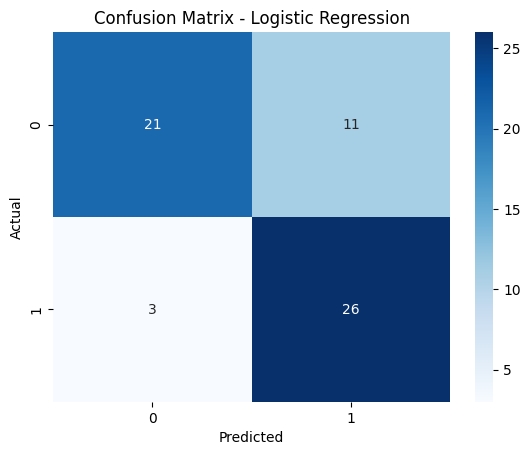

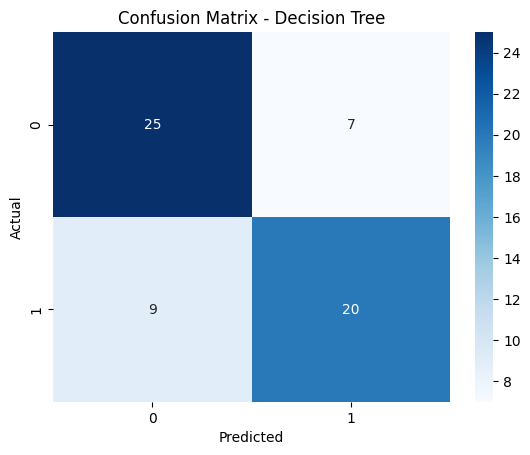

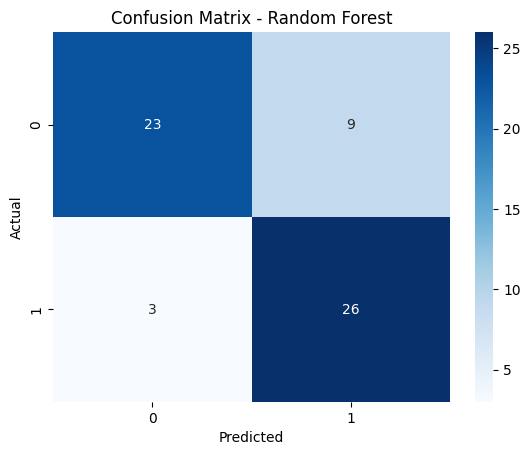

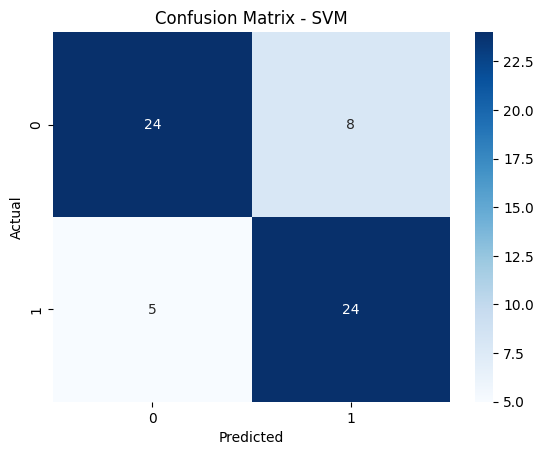

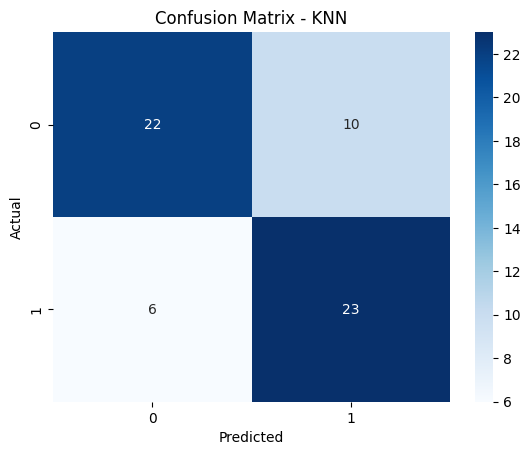

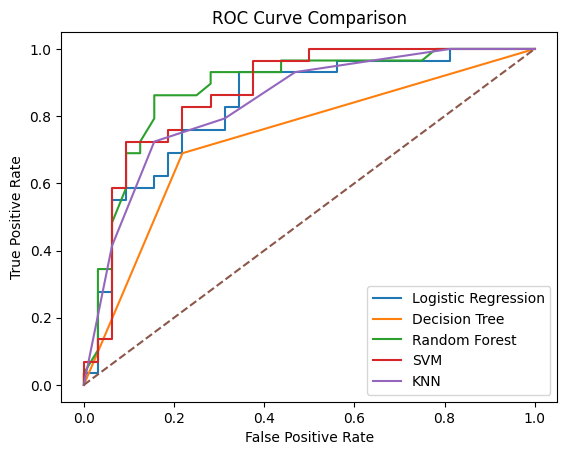

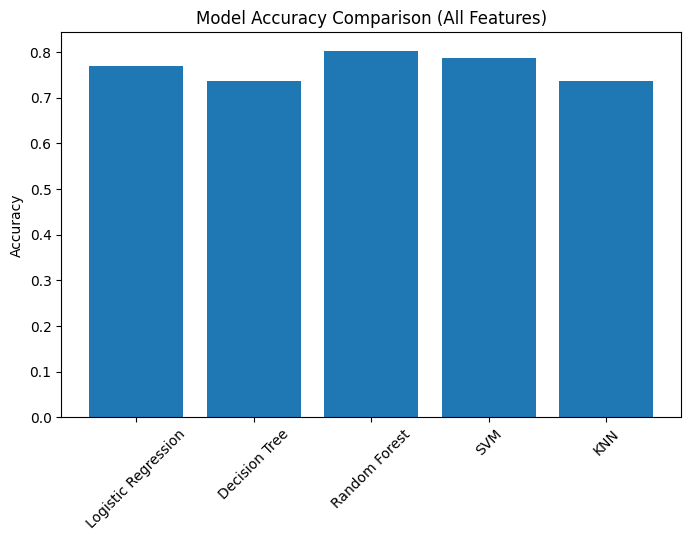

In [2]:
# ================================
# HEART DISEASE PREDICTION - BASELINE EXPERIMENT
# ================================

# 1. Import Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score, roc_curve
)

import matplotlib.pyplot as plt
import seaborn as sns


# ================================
# 2. Load Dataset
# ================================
data = pd.read_csv("heart.csv")

print("Original Shape:", data.shape)
print("Columns:", data.columns)


# ================================
# 3. Remove Duplicates (IMPORTANT)
# ================================
print("Duplicate Rows:", data.duplicated().sum())

data = data.drop_duplicates()

print("Shape After Removing Duplicates:", data.shape)


# ================================
# 4. Separate Features and Target
# ================================
X = data.drop("target", axis=1)
y = data["target"]


# ================================
# 5. Train-Test Split
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# ================================
# 6. Feature Scaling
# ================================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ================================
# 7. Define Models
# ================================
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True),  # Needed for ROC
    "KNN": KNeighborsClassifier()
}


# ================================
# 8. Train + Evaluate Models
# ================================
results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    results[name] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "ROC-AUC": roc
    }

    print(f"\n{name}")
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)
    print("ROC-AUC:", roc)


# ================================
# 9. Confusion Matrices
# ================================
for name, model in models.items():

    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


# ================================
# 10. ROC Curve Comparison
# ================================
plt.figure()

for name, model in models.items():

    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    plt.plot(fpr, tpr, label=name)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()


# ================================
# 11. Accuracy Bar Graph
# ================================
model_names = list(results.keys())
accuracies = [results[m]["Accuracy"] for m in model_names]

plt.figure(figsize=(8,5))
plt.bar(model_names, accuracies)

plt.title("Model Accuracy Comparison (All Features)")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)

plt.show()



Selected Features: Index(['age', 'cp', 'trestbps', 'chol', 'thalach', 'exang', 'oldpeak', 'ca'], dtype='object')

Logistic Regression (Chi-Square)
Accuracy: 0.7704918032786885
Precision: 0.7419354838709677
Recall: 0.7931034482758621
F1 Score: 0.7666666666666667
ROC-AUC: 0.8254310344827586

Decision Tree (Chi-Square)
Accuracy: 0.6885245901639344
Precision: 0.6666666666666666
Recall: 0.6896551724137931
F1 Score: 0.6779661016949152
ROC-AUC: 0.6885775862068966

Random Forest (Chi-Square)
Accuracy: 0.8360655737704918
Precision: 0.8275862068965517
Recall: 0.8275862068965517
F1 Score: 0.8275862068965517
ROC-AUC: 0.8529094827586208

SVM (Chi-Square)
Accuracy: 0.8360655737704918
Precision: 0.7878787878787878
Recall: 0.896551724137931
F1 Score: 0.8387096774193549
ROC-AUC: 0.8599137931034483

KNN (Chi-Square)
Accuracy: 0.7704918032786885
Precision: 0.7272727272727273
Recall: 0.8275862068965517
F1 Score: 0.7741935483870968
ROC-AUC: 0.8108836206896552


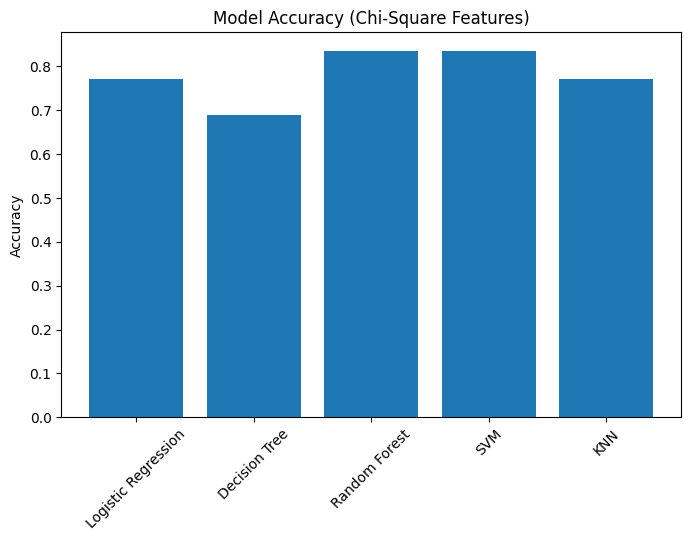

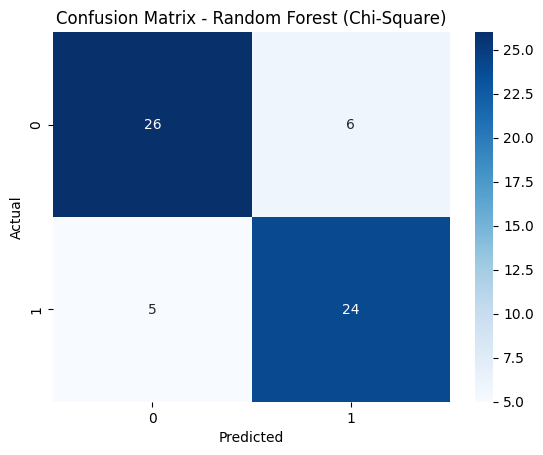

In [4]:
# ================================
# CHI-SQUARE FEATURE SELECTION EXPERIMENT
# ================================

from sklearn.feature_selection import SelectKBest, chi2

# Reload clean dataset (important to avoid scaled data issue)
data = pd.read_csv("heart.csv")
data = data.drop_duplicates()

X = data.drop("target", axis=1)
y = data["target"]

# ================================
# 1. Apply Chi-Square
# ================================
selector = SelectKBest(score_func=chi2, k=8)  # selecting top 8 features

X_new = selector.fit_transform(X, y)

# Get selected feature names
selected_features = X.columns[selector.get_support()]

print("Selected Features:", selected_features)


# ================================
# 2. Train-Test Split
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X_new, y, test_size=0.2, random_state=42
)


# ================================
# 3. Feature Scaling (AFTER selection)
# ================================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ================================
# 4. Models (same as before)
# ================================
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier()
}


# ================================
# 5. Train + Evaluate
# ================================
chi_results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    chi_results[name] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "ROC-AUC": roc
    }

    print(f"\n{name} (Chi-Square)")
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)
    print("ROC-AUC:", roc)


# ================================
# 6. Accuracy Comparison Graph
# ================================
model_names = list(chi_results.keys())
accuracies = [chi_results[m]["Accuracy"] for m in model_names]

plt.figure(figsize=(8,5))
plt.bar(model_names, accuracies)

plt.title("Model Accuracy (Chi-Square Features)")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)

plt.show()


# Confusion Matrix for Best Model (Chi-Square - Random Forest)

best_model = RandomForestClassifier()
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest (Chi-Square)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Selected Features (RFE): Index(['sex', 'cp', 'restecg', 'exang', 'oldpeak', 'slope', 'ca', 'thal'], dtype='object')

Logistic Regression (RFE)
Accuracy: 0.819672131147541
Precision: 0.7647058823529411
Recall: 0.896551724137931
F1 Score: 0.8253968253968254
ROC-AUC: 0.8588362068965517

Decision Tree (RFE)
Accuracy: 0.7213114754098361
Precision: 0.6875
Recall: 0.7586206896551724
F1 Score: 0.7213114754098361
ROC-AUC: 0.7586206896551724

Random Forest (RFE)
Accuracy: 0.8688524590163934
Precision: 0.8
Recall: 0.9655172413793104
F1 Score: 0.875
ROC-AUC: 0.9100215517241379

SVM (RFE)
Accuracy: 0.8360655737704918
Precision: 0.7714285714285715
Recall: 0.9310344827586207
F1 Score: 0.84375
ROC-AUC: 0.896551724137931

KNN (RFE)
Accuracy: 0.819672131147541
Precision: 0.7647058823529411
Recall: 0.896551724137931
F1 Score: 0.8253968253968254
ROC-AUC: 0.8911637931034483


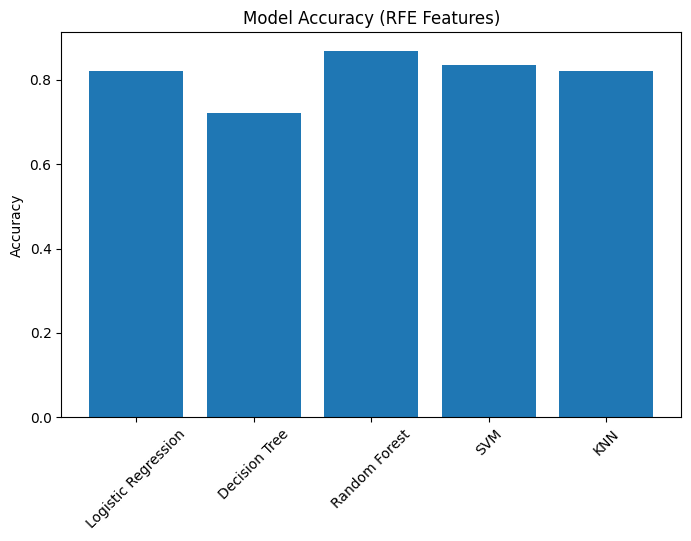

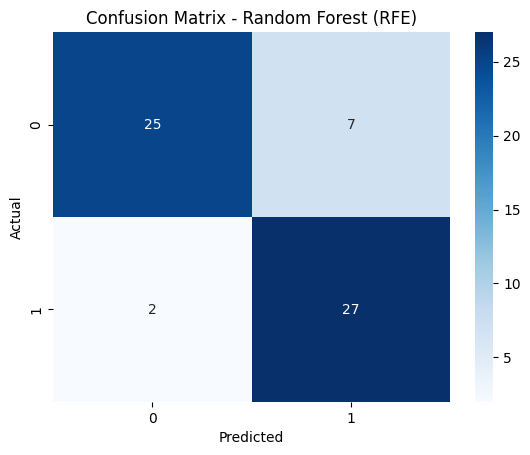

In [5]:
# ================================
# RFE FEATURE SELECTION EXPERIMENT
# ================================

from sklearn.feature_selection import RFE

# Reload clean dataset
data = pd.read_csv("heart.csv")
data = data.drop_duplicates()

X = data.drop("target", axis=1)
y = data["target"]

# ================================
# 1. Apply RFE
# ================================
model = LogisticRegression(max_iter=1000)

rfe = RFE(model, n_features_to_select=8)
X_rfe = rfe.fit_transform(X, y)

selected_features = X.columns[rfe.support_]

print("Selected Features (RFE):", selected_features)


# ================================
# 2. Train-Test Split
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X_rfe, y, test_size=0.2, random_state=42
)


# ================================
# 3. Feature Scaling
# ================================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ================================
# 4. Models
# ================================
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier()
}


# ================================
# 5. Train + Evaluate
# ================================
rfe_results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    rfe_results[name] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "ROC-AUC": roc
    }

    print(f"\n{name} (RFE)")
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)
    print("ROC-AUC:", roc)


# ================================
# 6. Accuracy Graph
# ================================
model_names = list(rfe_results.keys())
accuracies = [rfe_results[m]["Accuracy"] for m in model_names]

plt.figure(figsize=(8,5))
plt.bar(model_names, accuracies)

plt.title("Model Accuracy (RFE Features)")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)

plt.show()

# plotting the comparison matrix
best_model = RandomForestClassifier()
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest (RFE)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Explained Variance Ratio: [0.22731759 0.11978575 0.09812654 0.08351263 0.08002102 0.07247236
 0.06401963 0.06049309]
Total Variance Covered: 0.8057485926921115

Logistic Regression (PCA)
Accuracy: 0.819672131147541
Precision: 0.7368421052631579
Recall: 0.9655172413793104
F1 Score: 0.835820895522388
ROC-AUC: 0.8825431034482759

Decision Tree (PCA)
Accuracy: 0.7213114754098361
Precision: 0.6875
Recall: 0.7586206896551724
F1 Score: 0.7213114754098361
ROC-AUC: 0.7230603448275862

Random Forest (PCA)
Accuracy: 0.8032786885245902
Precision: 0.7575757575757576
Recall: 0.8620689655172413
F1 Score: 0.8064516129032258
ROC-AUC: 0.8706896551724137

SVM (PCA)
Accuracy: 0.8360655737704918
Precision: 0.7714285714285715
Recall: 0.9310344827586207
F1 Score: 0.84375
ROC-AUC: 0.9073275862068966

KNN (PCA)
Accuracy: 0.7868852459016393
Precision: 0.7666666666666667
Recall: 0.7931034482758621
F1 Score: 0.7796610169491526
ROC-AUC: 0.828125


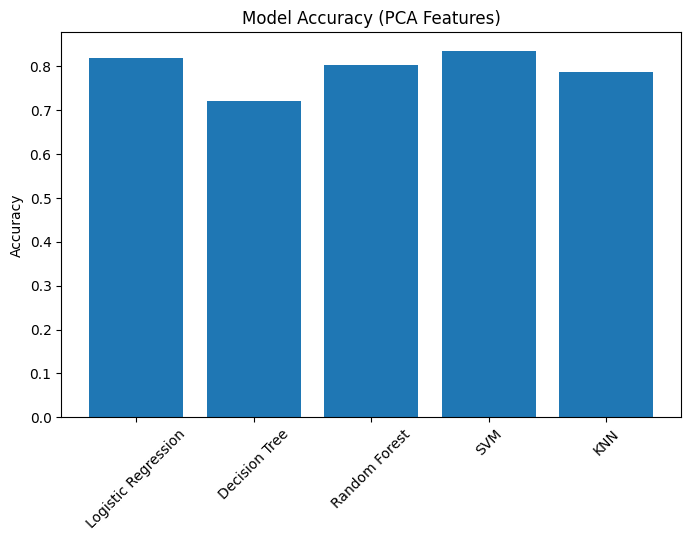

In [6]:
# ================================
# PCA FEATURE REDUCTION EXPERIMENT
# ================================

from sklearn.decomposition import PCA

# Reload clean dataset
data = pd.read_csv("heart.csv")
data = data.drop_duplicates()

X = data.drop("target", axis=1)
y = data["target"]

# ================================
# 1. Train-Test Split
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ================================
# 2. Feature Scaling (IMPORTANT before PCA)
# ================================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ================================
# 3. Apply PCA
# ================================
pca = PCA(n_components=8)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Variance Covered:", sum(pca.explained_variance_ratio_))


# ================================
# 4. Models
# ================================
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier()
}


# ================================
# 5. Train + Evaluate
# ================================
pca_results = {}

for name, model in models.items():

    model.fit(X_train_pca, y_train)

    y_pred = model.predict(X_test_pca)
    y_prob = model.predict_proba(X_test_pca)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    pca_results[name] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "ROC-AUC": roc
    }

    print(f"\n{name} (PCA)")
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)
    print("ROC-AUC:", roc)


# ================================
# 6. Accuracy Graph
# ================================
model_names = list(pca_results.keys())
accuracies = [pca_results[m]["Accuracy"] for m in model_names]

plt.figure(figsize=(8,5))
plt.bar(model_names, accuracies)

plt.title("Model Accuracy (PCA Features)")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)

plt.show()